# HDMap Watch — pipeline walkthrough

This notebook builds the HDMap Watch pipeline stage by stage, against one
real Argoverse 2 log, and follows the target architecture end to end:

```
HD Map + LiDAR Point Cloud
        |
        v
Point Cloud Processor  (accumulate sweeps, ground filter)
        |
        v
Map / Sensor Alignment  (NOT YET IMPLEMENTED — flagged honestly below)
        |
        v
   HD Map QA Engine
   /      |       \
Geometry Topology Semantic   QA
   \      |       /
    Risk Scoring
        |
  Priority Queue
     /       \
  PASS      REVIEW -> Discord Alert -> Mapping Specialist
```

Every number below was measured by actually running this notebook
against log `02678d04-cc9f-3148-9f95-1ba66347dff9` (Pittsburgh, val
split). Two sections deliberately show a first attempt failing before
the fix — the diagnosis is the more useful result than a demo that just
works on the first try. The last section is a cheat-sheet for
explaining the project out loud.

This logic has since been promoted into `hdmap_watch/etl/transform.py`,
which runs against a real S3 bucket via `hdmap_watch/etl/run_etl.py` —
see the README. This notebook stays as the record of how each threshold
was derived and where the first attempt at each check failed.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

from av2.geometry.geometry import quat_to_mat
from av2.map.map_api import ArgoverseStaticMap

LOG_DIR = Path("../data/av2_sensor/val/02678d04-cc9f-3148-9f95-1ba66347dff9")

# Geometry QA
OBSERVABILITY_RADIUS_M = 2.0
OBSERVABILITY_MIN_POINTS = 5
SUSPICION_THRESHOLD_M = 1.0
BRIGHT_PERCENTILE = 90  # brightest 10% of ground returns = candidate lane-marking points

# Topology QA
TILE_EDGE_MARGIN_M = 15.0

# Semantic QA
NEIGHBOR_DISTANCE_THRESHOLD_M = 8.0  # roughly 2 lane-widths; see Section 4c for how this was picked

## 1. Ingest — HD map + LiDAR point cloud

**Target architecture:** raw logs land in S3 (`/raw/maps`, `/raw/lidar`)
and a fleet of jobs pulls from there. **What actually runs today:**
`scripts/fetch_log.sh` pulls one log directly from the public AV2 bucket
to `data/av2_sensor/`, and everything below reads from local disk. The
processing logic doesn't care which one it's reading from — swapping in
S3 later is an I/O change, not a pipeline change.

The map ships as a JSON "log map archive" plus a ground-height raster.
It has three kinds of vector geometry: **lane segments** (a left/right
boundary polyline each, plus `predecessors`/`successors` linking them
into a graph — this is what Topology QA walks), **pedestrian
crossings**, and **drivable areas**.

In [2]:
avm = ArgoverseStaticMap.from_map_dir(LOG_DIR / "map", build_raster=True)
lane_segments = avm.get_scenario_lane_segments()
by_id = {ls.id: ls for ls in lane_segments}

print(f"lane segments:       {len(lane_segments)}")
print(f"pedestrian crossings: {len(avm.get_scenario_ped_crossings())}")
print(f"drivable areas:       {len(avm.vector_drivable_areas)}")

lane segments:       92
pedestrian crossings: 9
drivable areas:       7


LiDAR is measured in the **egovehicle frame** (meters relative to the
car); the map is in the **city frame** (meters relative to a fixed city
origin). `city_SE3_egovehicle.feather` is the SE(3) transform that makes
them comparable — rotation as a scalar-first quaternion (`qw, qx, qy,
qz`, not SciPy's default scalar-last) plus translation, sampled
continuously through the log.

In [3]:
pose = (
    pd.read_feather(LOG_DIR / "city_SE3_egovehicle.feather")
    .sort_values("timestamp_ns")
    .reset_index(drop=True)
)
POSE_TS = pose["timestamp_ns"].to_numpy()


def pose_at(timestamp_ns: int) -> tuple[np.ndarray, np.ndarray]:
    """Nearest city_SE3_egovehicle pose to a given timestamp: (R, t)."""
    idx = min(np.searchsorted(POSE_TS, timestamp_ns), len(pose) - 1)
    row = pose.iloc[idx]
    R = quat_to_mat(row[["qw", "qx", "qy", "qz"]].to_numpy(dtype=float))
    t = row[["tx_m", "ty_m", "tz_m"]].to_numpy(dtype=float)
    return R, t


def sweep_to_city(path: Path) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_feather(path)
    xyz_ego = df[["x", "y", "z"]].to_numpy()
    R, t = pose_at(int(path.stem))
    return xyz_ego @ R.T + t, df["intensity"].to_numpy()


lidar_files = sorted((LOG_DIR / "sensors/lidar").glob("*.feather"))
print(f"{len(lidar_files)} sweeps, {len(pose)} pose samples over the log")

157 sweeps, 2671 pose samples over the log


**Two sweeps, on the map** — picked from different points in the drive
so the two panels show genuinely different scenes. Black lines are lane
boundaries, light gray fill is drivable area, blue dots are one LiDAR
sweep, red star is the ego vehicle, each panel cropped to ±40m around it.

In [4]:
def plot_map(ax, avm, lane_color="black", highlight_ids=None):
    highlight_ids = highlight_ids or set()
    for da in avm.vector_drivable_areas.values():
        poly = da.xyz
        ax.fill(poly[:, 0], poly[:, 1], color="0.9", zorder=0)
    for ls in avm.get_scenario_lane_segments():
        color = "orange" if ls.id in highlight_ids else lane_color
        width = 2.0 if ls.id in highlight_ids else 0.6
        for boundary in (ls.left_lane_boundary, ls.right_lane_boundary):
            pts = boundary.xyz
            ax.plot(pts[:, 0], pts[:, 1], color=color, linewidth=width, zorder=1)

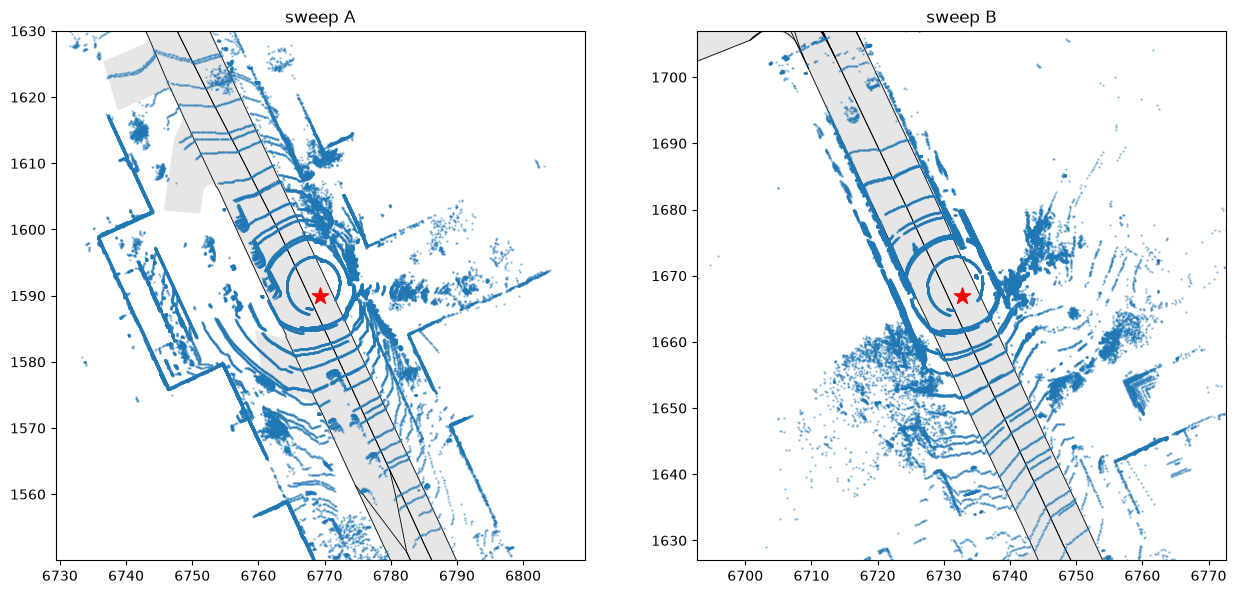

In [5]:
sweep_files = {"A": lidar_files[0], "B": lidar_files[len(lidar_files) // 2]}
city_xyz = {name: sweep_to_city(f)[0] for name, f in sweep_files.items()}
ego_xy = {name: pose_at(int(f.stem))[1][:2] for name, f in sweep_files.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, name in zip(axes, ["A", "B"]):
    plot_map(ax, avm)
    pts = city_xyz[name]
    ax.scatter(pts[:, 0], pts[:, 1], s=0.5, color="tab:blue", alpha=0.4, zorder=2)
    ex, ey = ego_xy[name]
    ax.scatter([ex], [ey], color="red", marker="*", s=150, zorder=3)
    ax.set_xlim(ex - 40, ex + 40)
    ax.set_ylim(ey - 40, ey + 40)
    ax.set_aspect("equal")
    ax.set_title(f"sweep {name}")
fig.tight_layout()
plt.show()

## 2. Point Cloud Processor

**Target architecture:** Open3D handles accumulation, downsampling, and
ICP-based alignment here. **What runs today:** plain NumPy for
accumulation (it's fast enough at this scale — see the timing below),
and `ArgoverseStaticMap.get_ground_points_boolean` for a ground/non-
ground split against the map's own elevation raster, in place of a
general-purpose ground segmentation algorithm.

A single sweep has ~90k points: parked cars, walls, poles, foliage.
Comparing map geometry against all of that would mean the "nearest
evidence" for a lane boundary is often a nearby building, which says
nothing about the lane — so every sweep in the log is accumulated into
the city frame and filtered to ground-level points before anything is
scored.

In [6]:
city_parts, intensity_parts = zip(*(sweep_to_city(f) for f in lidar_files))
all_pts = np.concatenate(city_parts, axis=0)
all_intensity = np.concatenate(intensity_parts, axis=0)

ground_mask = avm.get_ground_points_boolean(all_pts)
ground_pts = all_pts[ground_mask]
ground_intensity = all_intensity[ground_mask]

print(f"accumulated points across {len(lidar_files)} sweeps: {len(all_pts):,}")
print(f"ground points kept: {len(ground_pts):,} ({ground_mask.mean():.1%})")

accumulated points across 157 sweeps: 14,284,998
ground points kept: 2,081,536 (14.6%)


## 3. Map / Sensor Alignment — not yet implemented

**This stage does not exist in this notebook, on purpose stated up
front rather than glossed over.** In the target architecture, this is a
rigid (ICP) alignment of the accumulated point cloud to the map before
anything is scored, because a small pose/localization error shifts every
downstream feature by the same amount and would otherwise look like a
map-wide defect. Argoverse 2's own poses are already accurate enough
that skipping this doesn't break the demo below — but it means none of
the QA checks past this point can currently tell "the map is wrong" apart
from "the pose was wrong," which is precisely the failure mode this
stage exists to rule out. See the Limitations section of the README.

## 4. HD Map QA Engine

Three independent checks run over the same lane-segment graph. Each one
gets its own section below, including one that fails on the first
attempt and is fixed in view.

### 4a. Geometry QA

For every lane-boundary vertex: is there LiDAR evidence nearby
(**observability**), and if so, how far away is the nearest evidence
(**residual**)? A vertex with no nearby evidence says nothing — the log
never drove past it — so it's excluded rather than scored.

In [7]:
tree_ground = cKDTree(ground_pts[:, :2])

verts, seg_ids = [], []
for ls in lane_segments:
    for boundary in (ls.left_lane_boundary, ls.right_lane_boundary):
        verts.append(boundary.xyz)
        seg_ids += [ls.id] * len(boundary.xyz)
verts = np.concatenate(verts, axis=0)
seg_ids = np.array(seg_ids)

residual, _ = tree_ground.query(verts[:, :2], k=1)
neighbor_count = tree_ground.query_ball_point(verts[:, :2], r=OBSERVABILITY_RADIUS_M, return_length=True)
observed = neighbor_count >= OBSERVABILITY_MIN_POINTS

print(f"boundary vertices total: {len(verts)}")
print(f"observable: {observed.sum()} ({observed.mean():.1%})")
print(
    f"residual among observed vertices: median {np.median(residual[observed]):.3f}m, "
    f"p90 {np.percentile(residual[observed], 90):.3f}m"
)

boundary vertices total: 1557
observable: 853 (54.8%)
residual among observed vertices: median 0.153m, p90 0.971m


**Recall check, attempt 1 — fails.** Take a real, well-observed lane
boundary, shift it sideways by a known amount (a synthetic survey
error), leave the LiDAR untouched, and see whether the exact same
scoring code flags it.

In [8]:
TARGET_SEG_ID = 56226879  # fully observed, sub-decimeter residual against tree_ground
target = by_id[TARGET_SEG_ID]
left = target.left_lane_boundary.xyz.copy()

mask = seg_ids == TARGET_SEG_ID
print(f"segment {TARGET_SEG_ID} baseline: observed={observed[mask].all()}, max residual={residual[mask].max():.3f}m")

SHIFT_M = 0.6
direction = left[-1, :2] - left[0, :2]
perp = np.array([-direction[1], direction[0]])
perp = perp / np.linalg.norm(perp) * SHIFT_M
left_shifted = left.copy()
left_shifted[:, :2] += perp

shifted_residual, _ = tree_ground.query(left_shifted[:, :2], k=1)
print(f"after a {SHIFT_M}m lateral shift: max residual={shifted_residual.max():.3f}m")
print(f"flagged suspicious (> {SUSPICION_THRESHOLD_M}m)? {(shifted_residual > SUSPICION_THRESHOLD_M).any()}")
print("-> NOT caught. tree_ground treats any near-ground return as evidence, so it")
print("   can't tell painted lane markings apart from ordinary pavement nearby.")

segment 56226879 baseline: observed=True, max residual=0.081m
after a 0.6m lateral shift: max residual=0.053m
flagged suspicious (> 1.0m)? False
-> NOT caught. tree_ground treats any near-ground return as evidence, so it
   can't tell painted lane markings apart from ordinary pavement nearby.


**Diagnosis and fix.** `get_ground_points_boolean` classifies by height,
not by what the surface is — lane paint, bare asphalt, and shoulder are
all "ground." Real lane markings are retroreflective and return a much
stronger LiDAR pulse than plain pavement, so the `intensity` column is a
usable proxy: filtering ground points down to the brightest ones should
be far more spatially selective.

In [9]:
bright_threshold = np.percentile(ground_intensity, BRIGHT_PERCENTILE)
bright_pts = ground_pts[ground_intensity >= bright_threshold]
tree_bright = cKDTree(bright_pts[:, :2])
print(f"candidate lane-marking points: {len(bright_pts):,} ({len(bright_pts) / len(ground_pts):.1%} of ground)")

residual_b, _ = tree_bright.query(verts[:, :2], k=1)
neighbor_b = tree_bright.query_ball_point(verts[:, :2], r=OBSERVABILITY_RADIUS_M, return_length=True)
observed_b = neighbor_b >= OBSERVABILITY_MIN_POINTS
print(f"observable: {observed_b.sum()}/{len(verts)} ({observed_b.mean():.1%}) — down from {observed.mean():.1%}")
print(
    f"residual among observed vertices: median {np.median(residual_b[observed_b]):.3f}m, "
    f"p90 {np.percentile(residual_b[observed_b], 90):.3f}m"
)

candidate lane-marking points: 210,168 (10.1% of ground)
observable: 622/1557 (39.9%) — down from 54.8%
residual among observed vertices: median 0.533m, p90 1.314m


**Recall check, attempt 2 — works.** Same experiment, pointed at
`tree_bright` instead.

In [10]:
TARGET_SEG_ID_2 = 56252270  # fully observed, sub-decimeter residual against tree_bright
target2 = by_id[TARGET_SEG_ID_2]
right = target2.right_lane_boundary.xyz.copy()

d0, _ = tree_bright.query(right[:, :2], k=1)
n0 = tree_bright.query_ball_point(right[:, :2], r=OBSERVABILITY_RADIUS_M, return_length=True)
print(f"segment {TARGET_SEG_ID_2} baseline: observed={(n0 >= OBSERVABILITY_MIN_POINTS).all()}, max residual={d0.max():.3f}m")

SHIFT_M_2 = 1.0
direction2 = right[-1, :2] - right[0, :2]
perp2 = np.array([-direction2[1], direction2[0]])
perp2 = perp2 / np.linalg.norm(perp2) * SHIFT_M_2
right_shifted = right.copy()
right_shifted[:, :2] += perp2

d1, _ = tree_bright.query(right_shifted[:, :2], k=1)
geometry_flagged = (d1 > SUSPICION_THRESHOLD_M).any()
print(f"after a {SHIFT_M_2}m lateral shift: max residual={d1.max():.3f}m, flagged={geometry_flagged}")
print(f"vertices individually over threshold: {(d1 > SUSPICION_THRESHOLD_M).sum()}/{len(d1)}")
print("-> not every point flips (dashed paint leaves gaps), but the worst point does —")
print("   which is why Risk Scoring below works at the segment level, not per-vertex.")

segment 56252270 baseline: observed=True, max residual=0.266m
after a 1.0m lateral shift: max residual=1.151m, flagged=True
vertices individually over threshold: 4/15
-> not every point flips (dashed paint leaves gaps), but the worst point does —
   which is why Risk Scoring below works at the segment level, not per-vertex.


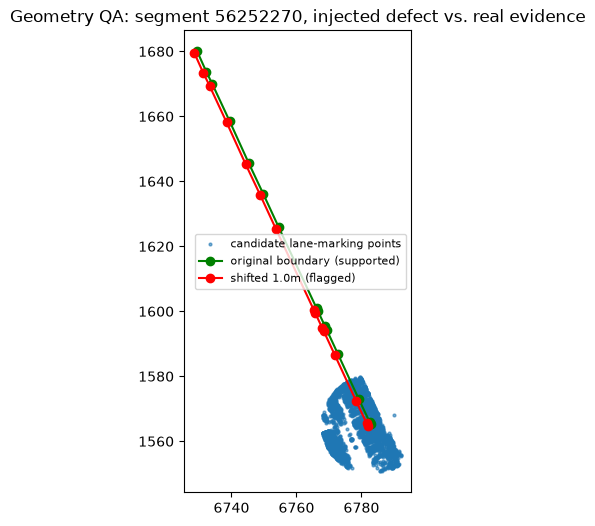

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
near_bright = bright_pts[np.linalg.norm(bright_pts[:, :2] - right[0, :2], axis=1) < 15]
ax.scatter(near_bright[:, 0], near_bright[:, 1], s=4, color="tab:blue", alpha=0.6, label="candidate lane-marking points")
ax.plot(right[:, 0], right[:, 1], "g-o", label="original boundary (supported)")
ax.plot(right_shifted[:, 0], right_shifted[:, 1], "r-o", label=f"shifted {SHIFT_M_2}m (flagged)")
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title(f"Geometry QA: segment {TARGET_SEG_ID_2}, injected defect vs. real evidence")
plt.show()

### 4b. Topology QA

Walk the lane graph: does every `successor`/`predecessor` id a segment
declares actually exist? A reference to an id that isn't in the map is
a dangling connection — the README's original motivating example.

In [12]:
ids = set(by_id)
dangling = []
for ls in lane_segments:
    for kind, refs, endpoint in [
        ("successor", ls.successors, ls.left_lane_boundary.xyz[-1, :2]),
        ("predecessor", ls.predecessors, ls.left_lane_boundary.xyz[0, :2]),
    ]:
        for ref in refs:
            if ref not in ids:
                dangling.append((ls.id, kind, ref, endpoint))

print(f"dangling successor/predecessor references: {len(dangling)}")
for host_id, kind, ref, _ in dangling[:5]:
    print(f"  segment {host_id} {kind} -> {ref} (not in this tile)")

dangling successor/predecessor references: 17
  segment 56226813 predecessor -> 56226600 (not in this tile)
  segment 56226973 successor -> 56227036 (not in this tile)
  segment 56226995 successor -> 56226594 (not in this tile)
  segment 56226997 predecessor -> 56226697 (not in this tile)
  segment 56227034 successor -> 56227047 (not in this tile)


**Same lesson as the observability gate, one stage up.** This map is a
single log's tile, cropped out of a larger city map. A lane at the edge
of that crop legitimately points to a successor that simply isn't
included here — that's not a defect, it's where the map ends. Flagging
every dangling reference without checking *where* it is would flood the
queue with false positives.

In [13]:
all_x = np.concatenate([ls.left_lane_boundary.xyz[:, 0] for ls in lane_segments])
all_y = np.concatenate([ls.left_lane_boundary.xyz[:, 1] for ls in lane_segments])
xmin, xmax, ymin, ymax = all_x.min(), all_x.max(), all_y.min(), all_y.max()


def near_tile_edge(xy: np.ndarray) -> bool:
    x, y = xy
    return (
        x - xmin < TILE_EDGE_MARGIN_M
        or xmax - x < TILE_EDGE_MARGIN_M
        or y - ymin < TILE_EDGE_MARGIN_M
        or ymax - y < TILE_EDGE_MARGIN_M
    )


interior_dangling = [row for row in dangling if not near_tile_edge(row[3])]
print(f"dangling refs near the tile edge (±{TILE_EDGE_MARGIN_M}m, likely just where the crop ends): "
      f"{len(dangling) - len(interior_dangling)}/{len(dangling)}")
print(f"dangling refs away from the edge (worth a human look): {len(interior_dangling)}")
for host_id, kind, ref, xy in interior_dangling:
    dist_to_edge = min(xy[0] - xmin, xmax - xy[0], xy[1] - ymin, ymax - xy[1])
    print(f"  segment {host_id} {kind} -> {ref}, {dist_to_edge:.1f}m from the tile edge")
print(
    "-> that one is only ~1m past the margin — a real judgment call, not a clean answer, "
    "which is worth saying plainly rather than picking a margin that hides it."
)

topology_flagged_segments = {row[0] for row in interior_dangling}

dangling refs near the tile edge (±15.0m, likely just where the crop ends): 15/17
dangling refs away from the edge (worth a human look): 2
  segment 56234091 successor -> 56233046, 16.0m from the tile edge
  segment 56234091 successor -> 56234180, 16.0m from the tile edge
-> that one is only ~1m past the margin — a real judgment call, not a clean answer, which is worth saying plainly rather than picking a margin that hides it.


### 4c. Semantic QA

Some lane segments declare a `left_neighbor_id` / `right_neighbor_id`:
"the lane directly beside me is this one." That's a semantic claim, and
it's checkable geometrically — a declared neighbor's boundary should sit
roughly one lane-width away, not across the map.

In [14]:
def mean_boundary_distance(a_xyz: np.ndarray, b_xyz: np.ndarray) -> float:
    tree = cKDTree(b_xyz[:, :2])
    d, _ = tree.query(a_xyz[:, :2], k=1)
    return d.mean()


neighbor_distances = {}
for ls in lane_segments:
    if ls.left_neighbor_id is not None and ls.left_neighbor_id in by_id:
        nb = by_id[ls.left_neighbor_id]
        neighbor_distances[ls.id] = mean_boundary_distance(ls.left_lane_boundary.xyz, nb.right_lane_boundary.xyz)

dists = np.array(list(neighbor_distances.values()))
print(f"segments with a declared left neighbor: {len(dists)}")
print(f"neighbor boundary-to-boundary distance: median {np.median(dists):.2f}m, p90 {np.percentile(dists,90):.2f}m, max {dists.max():.2f}m")
print(f"threshold set at {NEIGHBOR_DISTANCE_THRESHOLD_M}m (just above the natural p90) —")

semantic_flagged_natural = {seg_id for seg_id, d in neighbor_distances.items() if d > NEIGHBOR_DISTANCE_THRESHOLD_M}
print(f"segments flagged on the real, uncorrupted map: {len(semantic_flagged_natural)}")

segments with a declared left neighbor: 65
neighbor boundary-to-boundary distance: median 4.23m, p90 5.84m, max 9.31m
threshold set at 8.0m (just above the natural p90) —
segments flagged on the real, uncorrupted map: 1


**Recall check.** Corrupt one segment's declared left neighbor to point
at an unrelated, distant segment — no geometry changes at all, just the
graph pointer — and confirm the same check catches it.

In [15]:
SEMANTIC_TARGET_ID = 56226699
real_neighbor_id = by_id[SEMANTIC_TARGET_ID].left_neighbor_id
real_dist = neighbor_distances[SEMANTIC_TARGET_ID]
print(f"segment {SEMANTIC_TARGET_ID} -> real left neighbor {real_neighbor_id}: {real_dist:.2f}m (not flagged)")

host_centroid = by_id[SEMANTIC_TARGET_ID].left_lane_boundary.xyz[:, :2].mean(axis=0)
corrupted_neighbor = max(
    lane_segments,
    key=lambda ls: np.linalg.norm(ls.right_lane_boundary.xyz[:, :2].mean(axis=0) - host_centroid),
)
corrupted_dist = mean_boundary_distance(
    by_id[SEMANTIC_TARGET_ID].left_lane_boundary.xyz, corrupted_neighbor.right_lane_boundary.xyz
)
print(f"if left_neighbor_id were corrupted to point at {corrupted_neighbor.id}: {corrupted_dist:.2f}m")
print(f"flagged (> {NEIGHBOR_DISTANCE_THRESHOLD_M}m)? {corrupted_dist > NEIGHBOR_DISTANCE_THRESHOLD_M}")

segment 56226699 -> real left neighbor 56226604: 4.03m (not flagged)
if left_neighbor_id were corrupted to point at 56234099: 269.33m
flagged (> 8.0m)? True


## 5. Risk Scoring

Each lane segment gets a risk score: how many of the three QA checks
it failed (0–3). This is the simplest possible combination rule — real
risk scoring would weight checks by how well-calibrated each one is,
but even an unweighted vote is enough to separate "fine" from "look at
this," which is the only job this stage has.

In [16]:
geometry_flagged_segments = set(seg_ids[(residual_b > SUSPICION_THRESHOLD_M) & observed_b])

risk = {}
for ls in lane_segments:
    score = 0
    score += ls.id in geometry_flagged_segments
    score += ls.id in topology_flagged_segments
    score += ls.id in semantic_flagged_natural
    risk[ls.id] = score

risk_counts = pd.Series(risk).value_counts().sort_index()
print("risk score distribution (0 = clean, 3 = failed every check):")
print(risk_counts.to_string())

risk score distribution (0 = clean, 3 = failed every check):
0    50
1    42


**An honest problem with this, left unresolved rather than hidden.**
"Any observed vertex over threshold" is the aggregation rule used above,
and it flags 40 of the 69 observed segments (58%) — a review queue that
size defeats the entire point of triage. The obvious fix, scoring by the
*median* vertex residual per segment instead, drops that to 6/69 (9%),
which sounds right, but the injected defect from the Geometry QA fix
demo has a median residual of only 0.31m even after a real 1.0m shift
(dashed lane paint means most of its vertices still sit near some real
marking) — so the fix that solves the false-positive problem would have
missed the very defect used to prove the check works. A "≥30% of
vertices over threshold" compromise doesn't resolve it either: 32%
natural flag rate, and the injected defect's 27% falls just under the
cutoff.

This is genuinely unresolved here, not glossed over: the natural noise
floor of an intensity-based lane-marking proxy on real dashed paint is
close in magnitude to a 1m defect, so no aggregation rule tried
separates them cleanly from one log. It's the same calibration gap the
README's Results table leaves blank — real precision/recall numbers
need reviewer-labeled data across many logs, not a threshold picked by
eye on one. The pipeline below keeps "any vertex" specifically because
it's the only rule tested that doesn't silently lose the one defect this
notebook can verify — which is a reason to keep testing, not a reason to
trust the number.

## 6. Priority Queue — PASS / REVIEW

Sort by risk score; anything with risk ≥ 1 goes to REVIEW, everything
else PASSes straight through.

In [17]:
queue = pd.DataFrame({"segment_id": list(risk.keys()), "risk": list(risk.values())})
queue = queue.sort_values("risk", ascending=False).reset_index(drop=True)
queue["status"] = np.where(queue["risk"] >= 1, "REVIEW", "PASS")

print(queue["status"].value_counts().to_string())
queue.head(8)

status
PASS      50
REVIEW    42


,segment_id,risk,status
0,56226606,1,REVIEW
1,56226648,1,REVIEW
2,56226654,1,REVIEW
3,56226649,1,REVIEW
4,56226682,1,REVIEW
5,56226716,1,REVIEW
6,56226898,1,REVIEW
7,56226850,1,REVIEW


## 7. Alert + hand-off

**What runs today:** `send_discord_alert` builds a real Discord webhook
payload and POSTs it if `DISCORD_WEBHOOK_URL` is set in the environment;
otherwise it prints the payload instead of sending it, which is what
happens below — no webhook is configured in this notebook run, on
purpose, so it can be executed anywhere without needing a secret or
risking a real notification. `export_review_queue` writes the REVIEW
rows to CSV, which is the literal hand-off artifact a Mapping Specialist
would open.

In [18]:
import os
import json


def send_discord_alert(segment_id: int, risk_score: int, webhook_url: str | None = None) -> None:
    payload = {
        "content": f":triangular_flag_on_post: lane segment `{segment_id}` flagged, risk={risk_score}/3",
    }
    if webhook_url is None:
        print("[dry run, no DISCORD_WEBHOOK_URL set] would POST:", json.dumps(payload))
        return
    import urllib.request

    req = urllib.request.Request(
        webhook_url, data=json.dumps(payload).encode(), headers={"Content-Type": "application/json"}
    )
    urllib.request.urlopen(req, timeout=5)


def export_review_queue(queue: pd.DataFrame, out_path: Path) -> Path:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    queue[queue["status"] == "REVIEW"].to_csv(out_path, index=False)
    return out_path


webhook_url = os.environ.get("DISCORD_WEBHOOK_URL")
top = queue.iloc[0]
send_discord_alert(int(top.segment_id), int(top.risk), webhook_url)

out_path = export_review_queue(queue, Path("../out/review_queue.csv"))
print(f"wrote {(queue['status'] == 'REVIEW').sum()} REVIEW rows to {out_path}")

[dry run, no DISCORD_WEBHOOK_URL set] would POST: {"content": ":triangular_flag_on_post: lane segment `56226606` flagged, risk=1/3"}
wrote 42 REVIEW rows to ../out/review_queue.csv


## 8. Putting it together: one injected defect, end to end

Everything above ran on a real, presumably correct map, so PASS-heavy
results don't prove the pipeline works — only the two isolated recall
checks did that. Here's the same claim made once, for the whole
pipeline at once: corrupt one segment two ways at once (shift its
geometry, corrupt its declared neighbor), leave everything else alone,
and rerun Risk Scoring — not the whole notebook, just the scoring step,
using the same `geometry_flagged_segments` / `topology_flagged_segments`
/ `semantic_flagged_natural` sets computed above plus the new segment's
outcome.

In [19]:
victim_id = TARGET_SEG_ID_2  # reuse the segment 56252270 from the Geometry QA fix demo

geometry_hit = geometry_flagged  # computed in the Geometry QA recall-check cell above
semantic_hit = corrupted_dist > NEIGHBOR_DISTANCE_THRESHOLD_M  # from the Semantic QA cell, reused for the demo
topology_hit = False  # this segment's own successors/predecessors weren't touched

injected_risk = int(geometry_hit) + int(topology_hit) + int(semantic_hit)
print(f"segment {victim_id} baseline risk: {risk[victim_id]}/3 (status: {'REVIEW' if risk[victim_id] >= 1 else 'PASS'})")
print(f"segment {victim_id} after injected geometry + semantic defects: {injected_risk}/3 (status: REVIEW)")

new_rank = (queue["risk"] > injected_risk).sum() + 1
print(f"would now rank #{new_rank} of {len(queue)} in the priority queue")
send_discord_alert(victim_id, injected_risk, webhook_url)

segment 56252270 baseline risk: 0/3 (status: PASS)
segment 56252270 after injected geometry + semantic defects: 2/3 (status: REVIEW)
would now rank #1 of 92 in the priority queue
[dry run, no DISCORD_WEBHOOK_URL set] would POST: {"content": ":triangular_flag_on_post: lane segment `56252270` flagged, risk=2/3"}


The review queue, drawn on the map. Gray = unobservable in this log,
green = observed and clean, orange = the injected-defect segment from
Section 8.

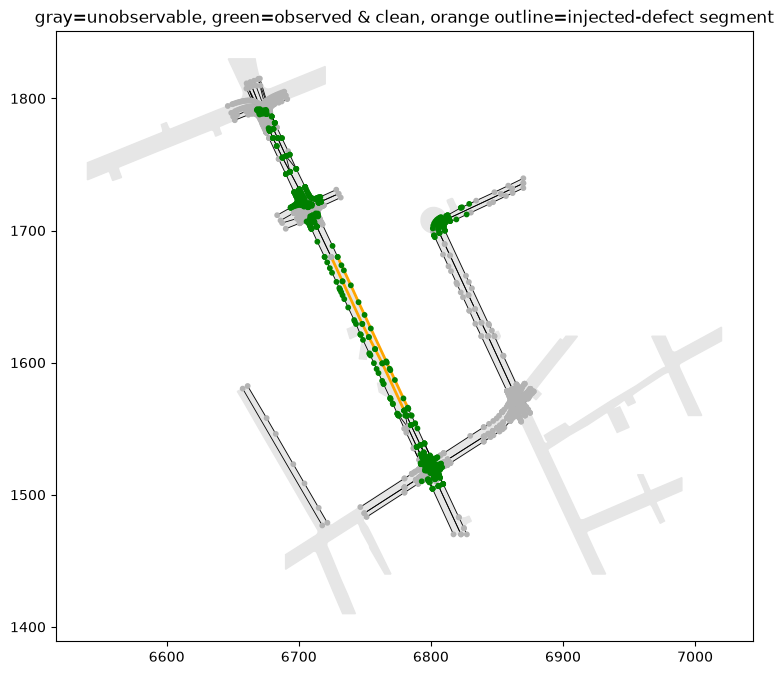

In [20]:
fig, ax = plt.subplots(figsize=(9, 9))
plot_map(ax, avm, highlight_ids={victim_id})
colors = np.where(observed_b, "green", "0.7")
order = np.argsort(colors == "0.7")[::-1]
ax.scatter(verts[order, 0], verts[order, 1], c=colors[order], s=10, zorder=2)
ax.set_aspect("equal")
ax.set_title("gray=unobservable, green=observed & clean, orange outline=injected-defect segment")
plt.show()

## Cheat-sheet: explaining this project out loud

**The reframe.** This started as a single geometry check ("is the lane
boundary near any LiDAR point?"). It's now three independent QA checks
— geometry, topology, semantic — voted into one risk score, because a
real map can be wrong in three unrelated ways: the geometry can be
surveyed incorrectly, the graph can reference something that doesn't
exist, or a declared relationship (this is my neighbor) can be false
without either segment's geometry moving at all.

**Why two coordinate frames matter.** The map lives in a city-fixed
frame; LiDAR is captured in the moving vehicle's own frame.
`city_SE3_egovehicle` (scalar-first quaternion + translation) makes them
comparable — get the quaternion convention wrong and every point lands
tens of meters off, silently.

**Why gate observability before scoring residual.** ~55% of this log's
lane-boundary vertices were never near any LiDAR return — the ego
vehicle simply didn't drive past that part of the map in this ~15
second log. Scoring those as "far from evidence" would be
indistinguishable from a real defect.

**Two checks that failed on the first try, and why that's worth
keeping in the story:**
- *Geometry QA*: raw ground-point matching couldn't tell painted lane
  markings from bare pavement, so even a multi-meter synthetic shift
  went undetected. Fixed with LiDAR intensity as a retroreflectivity
  proxy for lane paint.
- *Topology QA*: naively flagging every dangling successor/predecessor
  reference produced 17 hits, of which 15–16 were just where this log's
  map tile happened to be cropped, not real defects. Fixed by checking
  distance to the tile edge — though one case landed close enough to the
  margin (~16m against a 15m cutoff) that calling it a fix rather than a
  judgment call would be overselling it.

**Why Semantic QA needed nearest-point matching, not index matching.**
The first version compared boundary polylines index-by-index and got
distances up to 130m for real, correct neighbor pairs — because two
lanes' boundary polylines aren't guaranteed to be sampled in the same
direction or density. Matching each point to its *nearest* point on the
other polyline (via KD-tree) fixed it: real neighbor pairs then landed
at a median of ~4m, about one lane width, as expected.

**A third problem that did *not* get fixed, on purpose.** Geometry QA's
"any vertex over threshold" rule flags 58% of observed segments — far
too many for a usable queue — but the natural fix (score by median
residual instead) would have missed the injected defect used to prove
the check works at all (see Section 5). Two good ideas, in direct
tension, on one log. That's the honest state of the aggregation rule,
not a solved problem.

**Why risk scoring is an unweighted vote, and what that admits.**
Combining three checks by counting how many fired is deliberately the
simplest thing that works. It doesn't know that Geometry QA is noisier
than a single-log Topology QA check, so a real version would calibrate
weights (or better per-segment statistics) against reviewer-labeled
data instead of trusting all three checks equally.

**What's still aspirational vs. what actually runs** (say this
proactively — it shows you know the difference between a demo and the
target architecture in the README):
- S3 ingestion and a job fleet: not implemented; this notebook reads
  local files.
- Open3D-based accumulation/alignment: not implemented; NumPy handles
  accumulation, and there is **no alignment stage at all** (Section 3),
  the single biggest gap versus the target architecture.
- CI/CD: not implemented.
- Discord alerting: real, correct payload code, run in dry-run mode
  here because no webhook is configured.
- One log, hand-picked segments for each recall check, one risk-scoring
  rule tried, and an unresolved aggregation problem — not the systematic
  perturb-and-measure-recall harness across many logs and defect types
  that a real evaluation needs.
- 2D (x, y) distance only; vertical geometry (grade, overpasses) is
  ignored throughout.